# Dataset: Medical Cost Personal Datasets

## Impacto das Técnicas de Validação Cruzada na Estimativa de Erro

Este notebook implementa um estudo experimental inspirado em **Tougui et al. (2021)** para analisar se a **estimativa de erro** de um modelo supervisionado muda conforme a técnica de validação escolhida.

### Pergunta de investigação

> A escolha da estratégia de validação (Hold-out, K-Fold e Repeated K-Fold) altera, de forma mensurável, a estimativa do desempenho de generalização de um modelo de regressão?

### Dataset

- **Base de dados:** Medical Cost Personal Datasets
- **Variável alvo:** `charges`
- **Preditores:** `age`, `sex`, `bmi`, `children`, `smoker`, `region`

### Ideia central do estudo

Tougui et al. discutem que o protocolo de validação pode introduzir estimativas **mais otimistas** ou **mais estáveis** do erro, influenciando a interpretação do poder de generalização do modelo. Neste notebook, reproduzimos essa lógica para um problema de regressão e comparamos numericamente as métricas obtidas em diferentes estratégias de validação, focando exclusivamente em **MAE** e **RMSE**.


In [1]:
# Bibliotecas principais
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)


## 1. Configuração do projeto

Nesta secção definimos caminhos, variáveis do problema e uma função robusta para localizar o ficheiro CSV. Isso torna o notebook mais portátil caso seja executado a partir de diretórios diferentes.


In [ ]:
RANDOM_STATE = 42  #"semente", valor fixo, toda vez que rodar o código, obterá exatamente os mesmos resultados
TARGET = "charges"
NUMERIC_FEATURES = ["age", "bmi", "children"]
CATEGORICAL_FEATURES = ["sex", "smoker", "region"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def locate_dataset(filename: str = "insurance.csv") -> Path:
    """Procura o dataset em locais prováveis e devolve o respetivo caminho."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "trabalho" / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Não foi possível localizar {filename}. Verifique a pasta data/."
    )


DATA_PATH = locate_dataset()
DATA_PATH


WindowsPath('c:/Users/rodri/Documents/2semestre/AC/trabalho/data/insurance.csv')

## 2. Carregamento e inspeção inicial dos dados

Mesmo que o dataset não apresente valores omissos nesta versão, vamos manter a imputação no pipeline. Isso é importante por duas razões:

1. Cumpre o requisito metodológico do projeto.
2. Garante que o pré-processamento é encapsulado e aplicado **apenas dentro de cada fold**, evitando *data leakage*.


In [3]:
def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    expected_columns = set(ALL_FEATURES + [TARGET])
    missing_columns = expected_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltam colunas esperadas: {missing_columns}")
    return df


df = load_data(DATA_PATH)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


In [4]:
print(f"Dimensão do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.describe(include="all").T)
display(df.isna().sum().rename("missing_values").to_frame())


Dimensão do dataset: 1338 linhas x 7 colunas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.0000",NaN,NaN,NaN,39.2070,14.0500,18.0000,27.0000,39.0000,51.0000,64.0000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.0000",NaN,NaN,NaN,30.6634,6.0982,15.9600,26.2963,30.4000,34.6938,53.1300
children,"1,338.0000",NaN,NaN,NaN,1.0949,1.2055,0.0000,0.0000,1.0000,2.0000,5.0000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.0000",NaN,NaN,NaN,"13,270.4223","12,110.0112","1,121.8739","4,740.2872","9,382.0330","16,639.9125","63,770.4280"


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 3. Pipeline de pré-processamento e modelo

O pipeline abaixo foi construído para impedir vazamento de dados. Em vez de transformar o dataset completo antes da validação, cada transformação é aprendida **somente nos dados de treino** de cada divisão.

### Etapas implementadas

- **Numéricas (`age`, `bmi`, `children`)**
  - imputação pela mediana
  - padronização com `StandardScaler`
- **Categóricas (`sex`, `smoker`, `region`)**
  - imputação pela moda
  - codificação `OneHotEncoder`
- **Modelo final**
  - `LinearRegression`

Primeiro será feito com `LinearRegression` para manter um modelo base simples e interpretável, preservando o foco principal do estudo: comparar como diferentes estratégias de validação influenciam a estimativa de erro sem introduzir vazamento de dados.


In [5]:
def make_one_hot_encoder() -> OneHotEncoder:
    """Compatibilidade com versões diferentes do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline() -> Pipeline:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )
    return pipeline


pipeline = build_pipeline()
pipeline


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4. Funções auxiliares de avaliação

Vamos usar funções modulares para:

- calcular métricas por divisão;
- executar diferentes estratégias de validação com a mesma estrutura;
- produzir resultados comparáveis e fáceis de resumir;
- separar **métricas por split** de **métricas globais agregadas**.

Neste notebook, o desempenho será analisado apenas com:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**

Essas duas métricas permitem comparar, de forma objetiva, o erro médio absoluto e o impacto relativo de erros maiores, mantendo a análise focada estritamente no comportamento preditivo do modelo.


In [6]:
def compute_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    metrics = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
    }
    return metrics


def evaluate_resampling_strategy(
    X: pd.DataFrame,
    y: pd.Series,
    split_iterator,
    technique_name: str,
) -> tuple[pd.DataFrame, dict]:
    """Avalia uma técnica de validação e devolve:
    1. métricas por split
    2. métricas globais agregadas com todas as previsões fora da amostra
    """
    split_rows = []
    pooled_truth = []
    pooled_pred = []
    base_estimator = build_pipeline()

    for iteration, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        model = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pooled_truth.extend(y_test.to_numpy())
        pooled_pred.extend(np.asarray(y_pred))

        row = compute_metrics(y_test, y_pred)
        row["Technique"] = technique_name
        row["Iteration"] = iteration
        row["TestSize"] = len(test_idx)
        split_rows.append(row)

    split_df = pd.DataFrame(split_rows)

    pooled_metrics = compute_metrics(np.array(pooled_truth), np.array(pooled_pred))
    pooled_metrics["Technique"] = technique_name
    pooled_metrics["n_splits"] = len(split_df)
    pooled_metrics["n_predictions"] = len(pooled_truth)

    return split_df, pooled_metrics


def evaluate_holdout(X: pd.DataFrame, y: pd.Series) -> tuple[pd.DataFrame, dict]:
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.30,
        random_state=RANDOM_STATE,
    )
    return evaluate_resampling_strategy(
        X=X,
        y=y,
        split_iterator=[(train_idx, test_idx)],
        technique_name="Hold-out (70/30)",
    )


## 5. Execução do estudo experimental

As técnicas comparadas serão:

- **Hold-out (70/30)**: uma única divisão treino/teste;
- **K-Fold CV (k = 10)**: média do desempenho em 10 folds;
- **Repeated K-Fold (10 folds, 5 repetições)**: mede variabilidade adicional.

A comparação fica concentrada em estratégias usuais e computacionalmente mais leves, mantendo a análise alinhada com o objetivo de estudar a estabilidade das estimativas de erro.


In [7]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

strategies = [
    ("Hold-out (70/30)", None),
    ("K-Fold CV (10)", KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE).split(X, y)),
    (
        "Repeated K-Fold (10x5)",
        RepeatedKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE).split(X, y),
    ),
]

split_results = []
pooled_results = []

for technique_name, splitter in strategies:
    if technique_name == "Hold-out (70/30)":
        split_df, pooled_metrics = evaluate_holdout(X, y)
    else:
        split_df, pooled_metrics = evaluate_resampling_strategy(
            X=X,
            y=y,
            split_iterator=splitter,
            technique_name=technique_name,
        )

    split_results.append(split_df)
    pooled_results.append(pooled_metrics)


results_df = pd.concat(split_results, ignore_index=True)
pooled_df = pd.DataFrame(pooled_results)

print("Número total de avaliações armazenadas:", len(results_df))
display(results_df.head())
display(pooled_df)


Número total de avaliações armazenadas: 61


,MAE,RMSE,Technique,Iteration,TestSize
0,"4,145.4506","5,812.1003",Hold-out (70/30),1,402
1,"4,087.5343","5,681.1839",K-Fold CV (10),1,134
2,"4,257.1688","5,938.8562",K-Fold CV (10),2,134
3,"4,022.6540","5,868.7254",K-Fold CV (10),3,134
4,"4,434.2396","6,344.5496",K-Fold CV (10),4,134


,MAE,RMSE,Technique,n_splits,n_predictions
0,"4,145.4506","5,812.1003",Hold-out (70/30),1,402
1,"4,204.8275","6,084.1872",K-Fold CV (10),10,1338
2,"4,203.7421","6,088.7246",Repeated K-Fold (10x5),50,6690


## 6. Tabela resumo das métricas

Para cada técnica, apresentamos:

- **média** e **desvio padrão** das métricas ao longo dos splits;
- **métricas agregadas globais** com base em todas as previsões fora da amostra.

Esta distinção é útil porque:

- a média/desvio padrão mostram **estabilidade**;
- a métrica agregada resume o desempenho global de generalização.

Como o foco foi reduzido para **MAE** e **RMSE**, a tabela fica mais direta e concentrada nas medidas de erro mais relevantes para o estudo.


In [8]:
summary_df = (
    results_df.groupby("Technique")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        n_evaluations=("Iteration", "count"),
    )
    .reset_index()
)

summary_df = summary_df.merge(
    pooled_df[["Technique", "MAE", "RMSE"]],
    on="Technique",
    how="left",
    suffixes=("_split", "_pooled"),
)

summary_df = summary_df.rename(
    columns={
        "MAE": "MAE_pooled",
        "RMSE": "RMSE_pooled",
    }
)

summary_df = summary_df.sort_values("MAE_pooled").reset_index(drop=True)
display(summary_df)


,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,n_evaluations,MAE_pooled,RMSE_pooled
0,Hold-out (70/30),"4,145.4506",NaN,"5,812.1003",NaN,1,"4,145.4506","5,812.1003"
1,Repeated K-Fold (10x5),"4,203.9652",417.2952,"6,055.7441",641.4425,50,"4,203.7421","6,088.7246"
2,K-Fold CV (10),"4,204.6377",280.1639,"6,070.3504",436.0309,10,"4,204.8275","6,084.1872"


## 7. Boxplot do MAE por técnica

O boxplot permite comparar visualmente:

- a posição central do erro;
- a dispersão das estimativas;
- a presença de técnicas potencialmente **mais otimistas**;
- a variabilidade introduzida por diferentes partições dos dados.

Segundo a discussão teórica inspirada em Tougui et al., técnicas com menor variabilidade tendem a fornecer estimativas mais estáveis da capacidade de generalização, enquanto uma única partição Hold-out pode induzir conclusões dependentes do acaso da divisão escolhida.


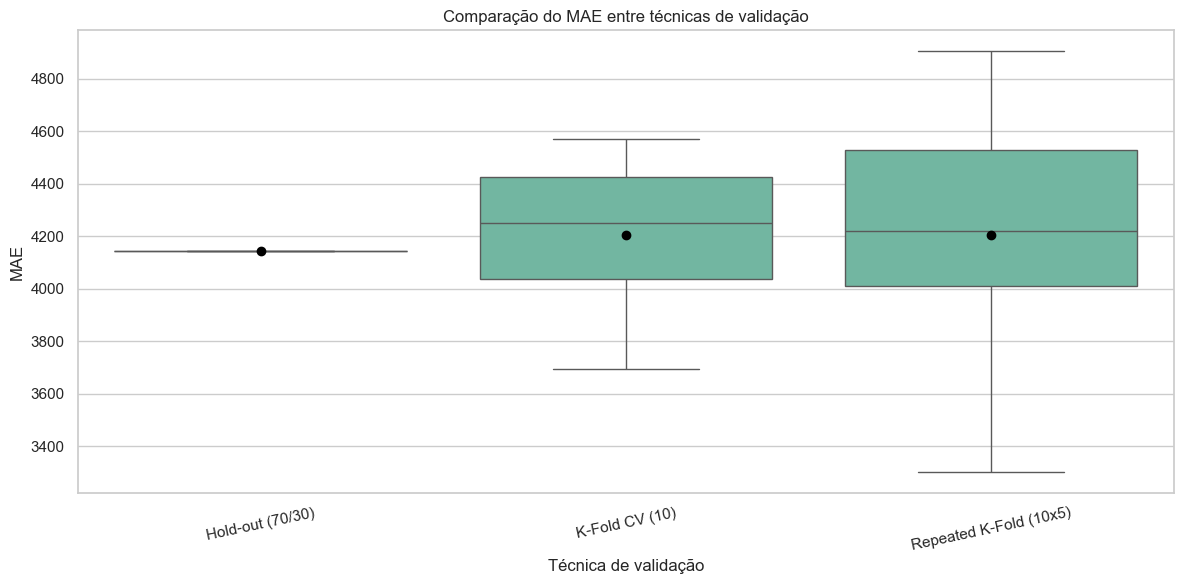

In [9]:
plot_df = results_df.copy()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=plot_df,
    x="Technique",
    y="MAE",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Comparação do MAE entre técnicas de validação")
ax.set_xlabel("Técnica de validação")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 8. Leitura interpretativa dos resultados

Nesta etapa, geramos uma interpretação textual automática para apoiar a discussão no relatório. O objetivo não é substituir a análise crítica, mas estruturar uma leitura coerente com os conceitos de **sobreajuste**, **otimismo da validação** e **generalização**, focando apenas em **MAE** e **RMSE**.


In [11]:
def build_interpretation(summary: pd.DataFrame) -> str:
    best_mae_row = summary.loc[summary["MAE_pooled"].idxmin()]
    best_rmse_row = summary.loc[summary["RMSE_pooled"].idxmin()]
    most_stable_row = summary.loc[summary["MAE_std"].fillna(np.inf).idxmin()]
    holdout_row = summary.loc[summary["Technique"] == "Hold-out (70/30)"].iloc[0]
    kfold_row = summary.loc[summary["Technique"] == "K-Fold CV (10)"].iloc[0]
    repeated_row = summary.loc[summary["Technique"] == "Repeated K-Fold (10x5)"].iloc[0]

    interpretation = f'''
Melhor MAE agregado: {best_mae_row["Technique"]} ({best_mae_row["MAE_pooled"]:.2f}).

Melhor RMSE agregado: {best_rmse_row["Technique"]} ({best_rmse_row["RMSE_pooled"]:.2f}).

Técnica com menor variabilidade do MAE entre splits: {most_stable_row["Technique"]}
(desvio padrão = {most_stable_row["MAE_std"]:.2f}).

Leitura teórica:
- O Hold-out usa apenas uma divisão e, por isso, pode produzir uma estimativa mais dependente do acaso.
- O K-Fold reduz essa dependência ao reutilizar o dataset em múltiplas divisões.
- O Repeated K-Fold amplia a robustez da estimativa, pois repete o processo com novas partições e revela melhor a variabilidade experimental.

Comparação direta:
- Hold-out MAE agregado: {holdout_row["MAE_pooled"]:.2f}
- K-Fold MAE agregado: {kfold_row["MAE_pooled"]:.2f}
- Repeated K-Fold MAE agregado: {repeated_row["MAE_pooled"]:.2f}
- Hold-out RMSE agregado: {holdout_row["RMSE_pooled"]:.2f}
- K-Fold RMSE agregado: {kfold_row["RMSE_pooled"]:.2f}
- Repeated K-Fold RMSE agregado: {repeated_row["RMSE_pooled"]:.2f}

Conclusão preliminar:
Se as estimativas diferirem entre si, então a experiência numérica sustenta a hipótese de Tougui et al. de que a técnica de validação afeta a avaliação do desempenho. 
Quando o Hold-out parece ligeiramente melhor, isso não deve ser interpretado automaticamente como melhor capacidade de generalização; pode ser apenas uma divisão favorável. 
Já as técnicas repetidas e com múltiplos folds tendem a produzir uma visão mais estável e confiável do erro esperado fora da amostra.
'''.strip()
    return interpretation


print(build_interpretation(summary_df))


Melhor MAE agregado: Hold-out (70/30) (4145.45).

Melhor RMSE agregado: Hold-out (70/30) (5812.10).

Técnica com menor variabilidade do MAE entre splits: K-Fold CV (10)
(desvio padrão = 280.16).

Leitura teórica:
- O Hold-out usa apenas uma divisão e, por isso, pode produzir uma estimativa mais dependente do acaso.
- O K-Fold reduz essa dependência ao reutilizar o dataset em múltiplas divisões.
- O Repeated K-Fold amplia a robustez da estimativa, pois repete o processo com novas partições e revela melhor a variabilidade experimental.

Comparação direta:
- Hold-out MAE agregado: 4145.45
- K-Fold MAE agregado: 4204.83
- Repeated K-Fold MAE agregado: 4203.74
- Hold-out RMSE agregado: 5812.10
- K-Fold RMSE agregado: 6084.19
- Repeated K-Fold RMSE agregado: 6088.72

Conclusão preliminar:
Se as estimativas diferirem entre si, então a experiência numérica sustenta a hipótese de Tougui et al. de que a técnica de validação afeta a avaliação do desempenho. 
Quando o Hold-out parece ligeiramente 

## 9. Conclusão

Este notebook mostra, de forma reprodutível, que a **estimativa do erro não é única**: ela depende do protocolo de validação escolhido.

### Síntese conceptual

- **Hold-out** é simples, mas pode ser instável e otimista/pessimista conforme a partição.
- **K-Fold** tende a fornecer uma estimativa mais equilibrada.
- **Repeated K-Fold** é especialmente útil para quantificar a variabilidade da avaliação.

### Relação com generalização e sobreajuste

Se uma técnica produz estimativas sistematicamente mais favoráveis do que outras, isso sugere uma avaliação potencialmente **otimista**, o que pode mascarar problemas de **generalização**. Assim, a escolha da validação faz parte da própria metodologia científica do modelo e não deve ser tratada como um detalhe secundário.

### Métricas mantidas

- **MAE** resume a magnitude média do erro.
- **RMSE** penaliza mais fortemente erros grandes e ajuda a perceber maior dispersão nas previsões.

### Próximos passos possíveis

- repetir o estudo com `RandomForestRegressor`;
- comparar tempos computacionais entre estratégias;
- aplicar testes estatísticos às distribuições das métricas;
- discutir o efeito do tamanho amostral na escolha do protocolo de validação.
